In [1]:
import pandas as pd

prediction_all = pd.read_csv("../Data/Merged/Prediction_all.csv")
prediction_with_sofr = pd.read_csv("../Data/Merged/Prediction_all_with_sofr.csv")

print("\n=== Prediction_all_with_sofr.csv ===")
print(f"Shape: {prediction_with_sofr.shape}")
display(prediction_with_sofr.head())


=== Prediction_all_with_sofr.csv ===
Shape: (6012, 27)


,decision_date,observed_day_pst,kalshi_C25,kalshi_C50+,kalshi_H0,kalshi_H25,kalshi_H50,kalshi_H50+,polymarket_C25,polymarket_C50,...,polymarket_H75,sofr_method,sofr_pre_rate,sofr_post_rate,sofr_expected_change,sofr_p_minus_50,sofr_p_minus_25,sofr_p_0,sofr_p_plus_25,sofr_p_plus_50
0,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,ois_anchor_long,0.042309,0.046613,0.004304,0.0,0.0,0.0,0.278304,0.721696
1,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,ois_anchor_short,0.042309,0.046486,0.004177,0.0,0.0,0.0,0.329273,0.670727
2,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,raw_futures_ois,0.042309,0.046486,0.004177,0.0,0.0,0.0,0.329273,0.670727
3,2023-02-01,2022-12-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,ois_anchor_long,0.042341,0.046492,0.004150,0.0,0.0,0.0,0.339948,0.660052
4,2023-02-01,2022-12-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,ois_anchor_short,0.042341,0.046464,0.004123,0.0,0.0,0.0,0.350880,0.649120


In [2]:
import numpy as np
import matplotlib.pyplot as plt

df = prediction_with_sofr.copy()
df["observed_day_pst"] = pd.to_datetime(df["observed_day_pst"])

# BPS mapping for each source
kalshi_map = {
    "kalshi_C50+": -50, "kalshi_C25": -25, "kalshi_H0": 0,
    "kalshi_H25": 25, "kalshi_H50": 50, "kalshi_H50+": 50,
}
poly_map = {
    "polymarket_C75+": -75, "polymarket_C50+": -50, "polymarket_C50": -50,
    "polymarket_C25": -25, "polymarket_H0": 0, "polymarket_H25": 25,
    "polymarket_H25+": 25, "polymarket_H50": 50, "polymarket_H50+": 50,
    "polymarket_H75": 75,
}
sofr_map = {
    "sofr_p_minus_50": -50, "sofr_p_minus_25": -25, "sofr_p_0": 0,
    "sofr_p_plus_25": 25, "sofr_p_plus_50": 50,
}

def expected_change(row, col_map):
    total_prob = 0
    weighted = 0
    for col, bps in col_map.items():
        p = row.get(col)
        if pd.notna(p) and p != "":
            p = float(p)
            weighted += p * bps
            total_prob += p
    if total_prob < 0.01:
        return np.nan
    return weighted / total_prob

df["kalshi_expected_bps"] = df.apply(lambda r: expected_change(r, kalshi_map), axis=1)
df["poly_expected_bps"] = df.apply(lambda r: expected_change(r, poly_map), axis=1)
df["sofr_expected_bps"] = df["sofr_expected_change"] * 10000  # decimal -> bps

# Pick a meeting with good data coverage across all three sources
meetings = df.groupby("decision_date").apply(
    lambda g: g[["kalshi_expected_bps", "poly_expected_bps", "sofr_expected_bps"]].notna().all(axis=1).sum()
).sort_values(ascending=False)
print("Meetings ranked by # of days with all 3 sources:")
print(meetings.head(10))

best_meeting = meetings.index[0]
print(f"\nPlotting: {best_meeting}")

Meetings ranked by # of days with all 3 sources:
decision_date
2025-12-10    270
2026-01-28    258
2026-03-18    246
2026-04-29    213
2025-10-29    183
2026-06-17    156
2023-09-20    117
2024-11-07    111
2024-09-18    108
2025-03-19    105
dtype: int64

Plotting: 2025-12-10


/var/folders/7v/dpscvhb97g76nms2j3w6lh2w0000gn/T/ipykernel_31760/1497760847.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meetings = df.groupby("decision_date").apply(


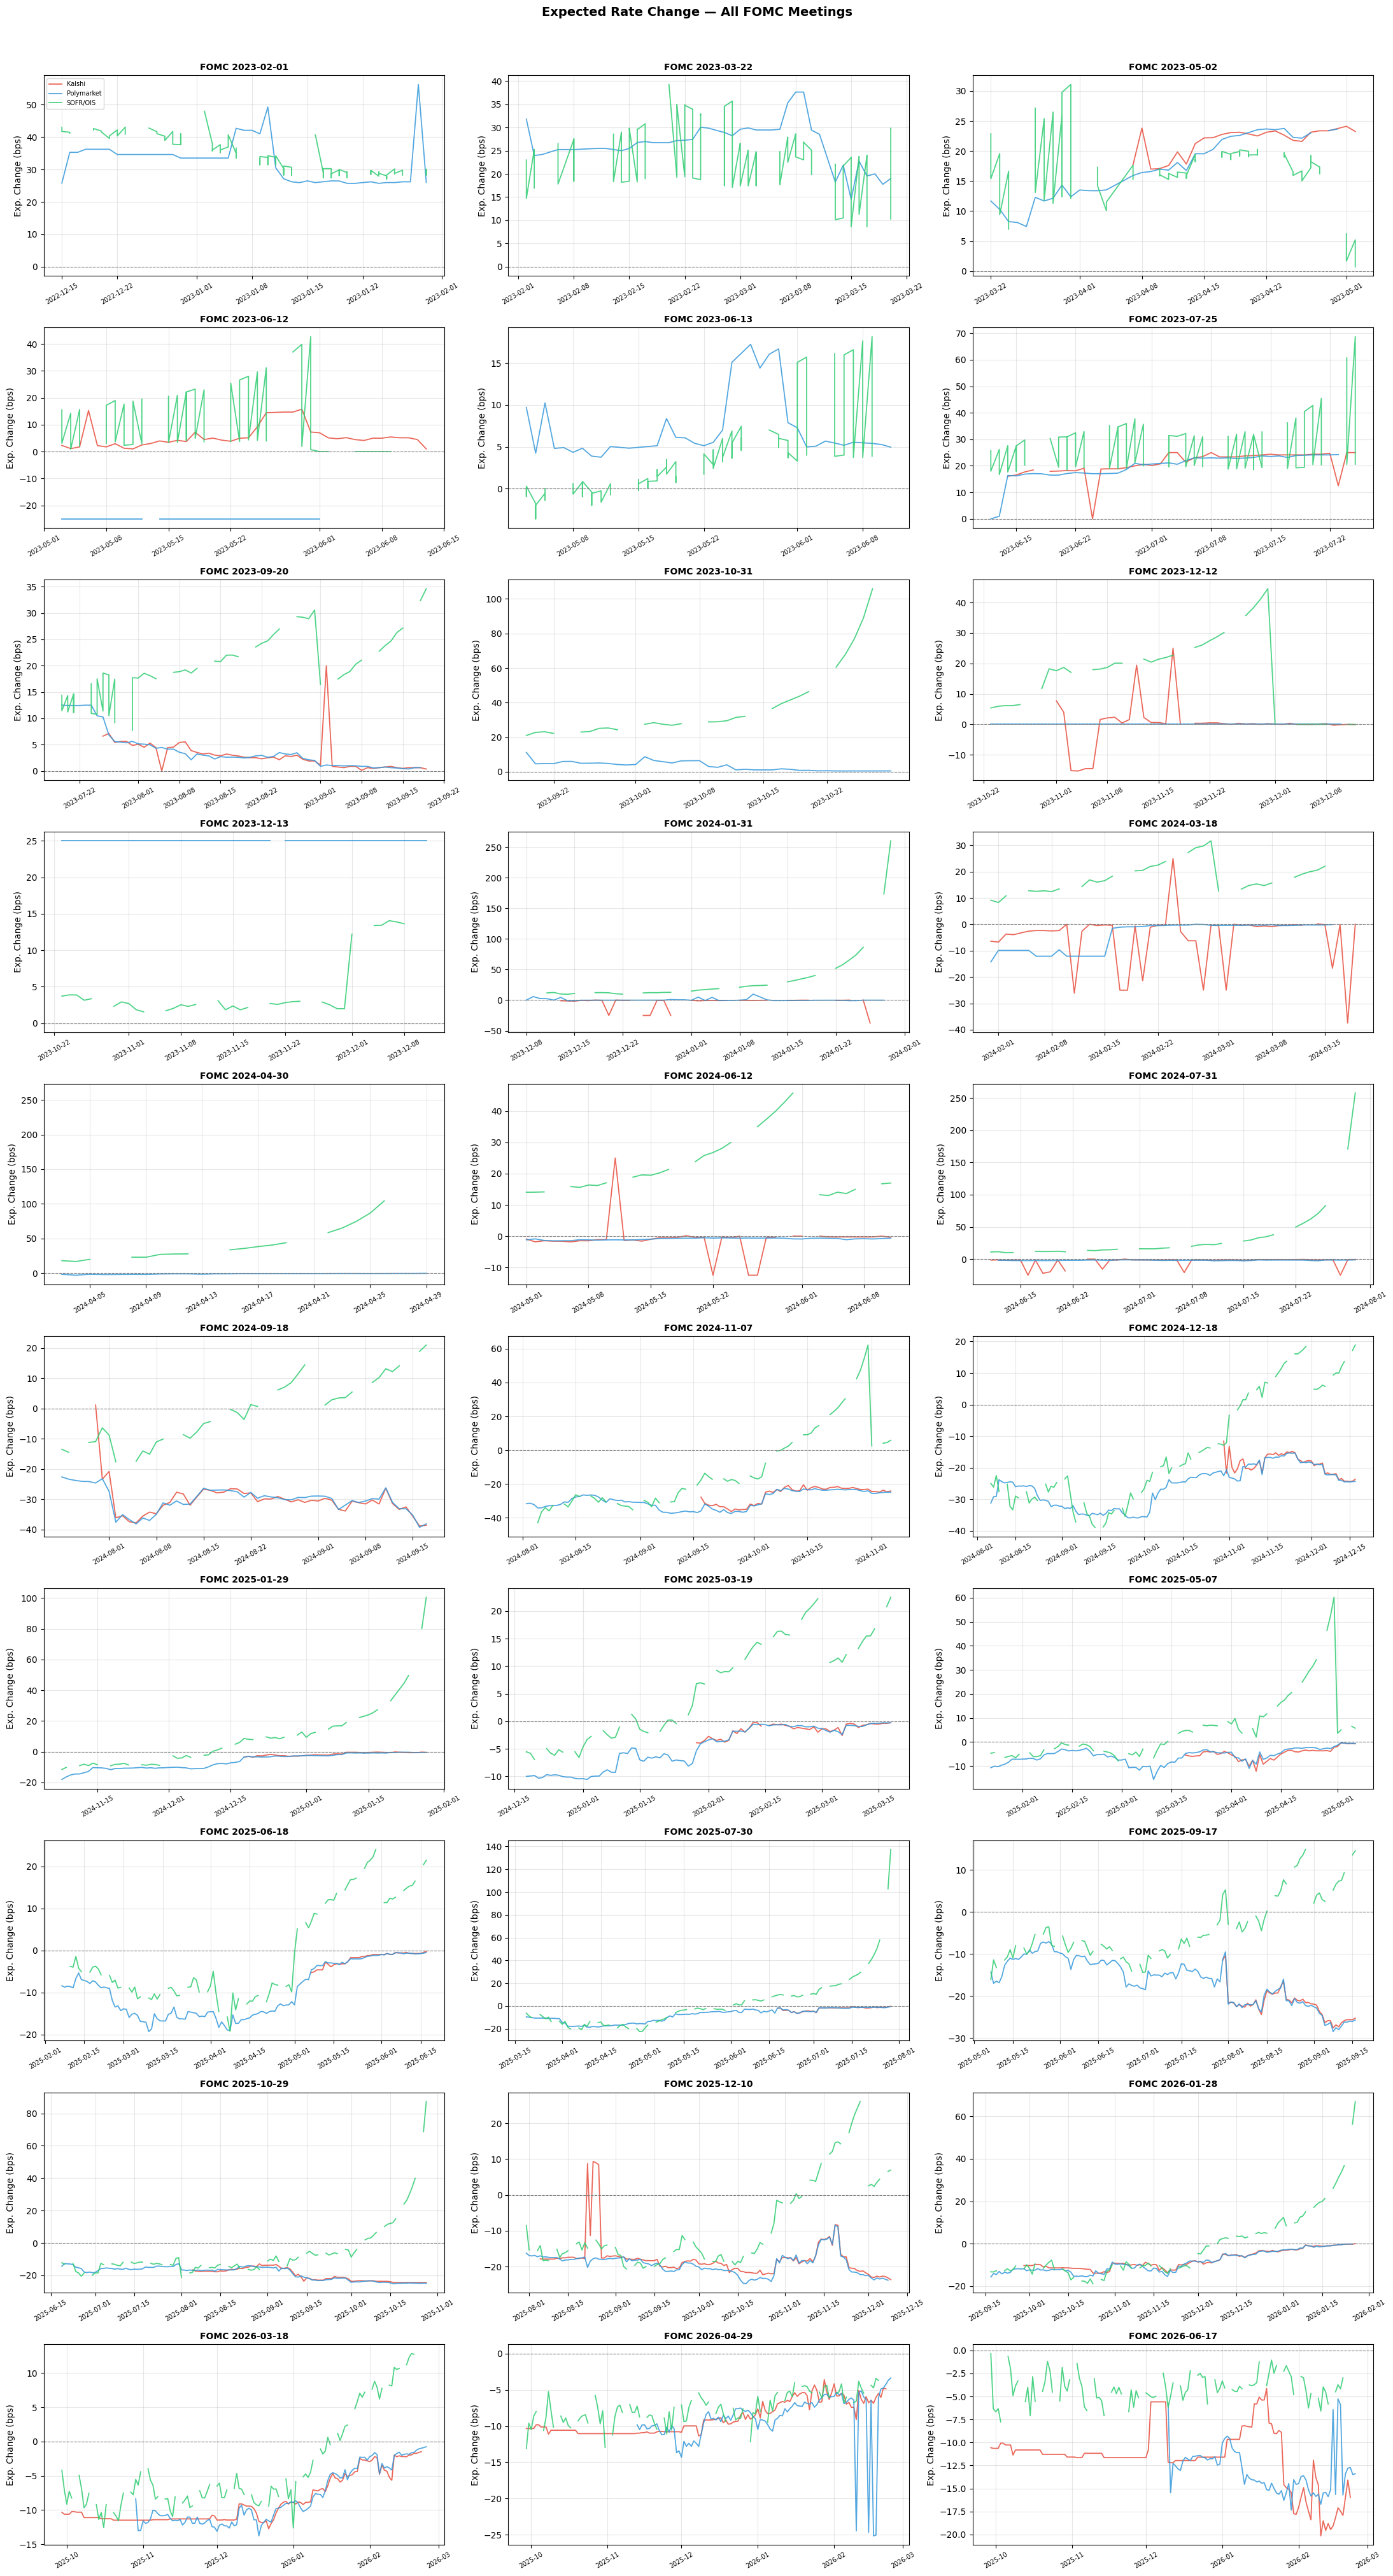

In [3]:
all_meetings = sorted(df["decision_date"].unique())
n = len(all_meetings)
cols = 3
rows_grid = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(22, 4 * rows_grid))
axes = axes.flatten()

for i, meeting in enumerate(all_meetings):
    ax = axes[i]
    meeting_df = df[df["decision_date"] == meeting].sort_values("observed_day_pst")

    ax.plot(meeting_df["observed_day_pst"], meeting_df["kalshi_expected_bps"],
            label="Kalshi", color="#e74c3c", linewidth=1.3, alpha=0.85)
    ax.plot(meeting_df["observed_day_pst"], meeting_df["poly_expected_bps"],
            label="Polymarket", color="#3498db", linewidth=1.3, alpha=0.85)
    ax.plot(meeting_df["observed_day_pst"], meeting_df["sofr_expected_bps"],
            label="SOFR/OIS", color="#2ecc71", linewidth=1.3, alpha=0.85)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"FOMC {meeting}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Exp. Change (bps)")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Expected Rate Change — All FOMC Meetings", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

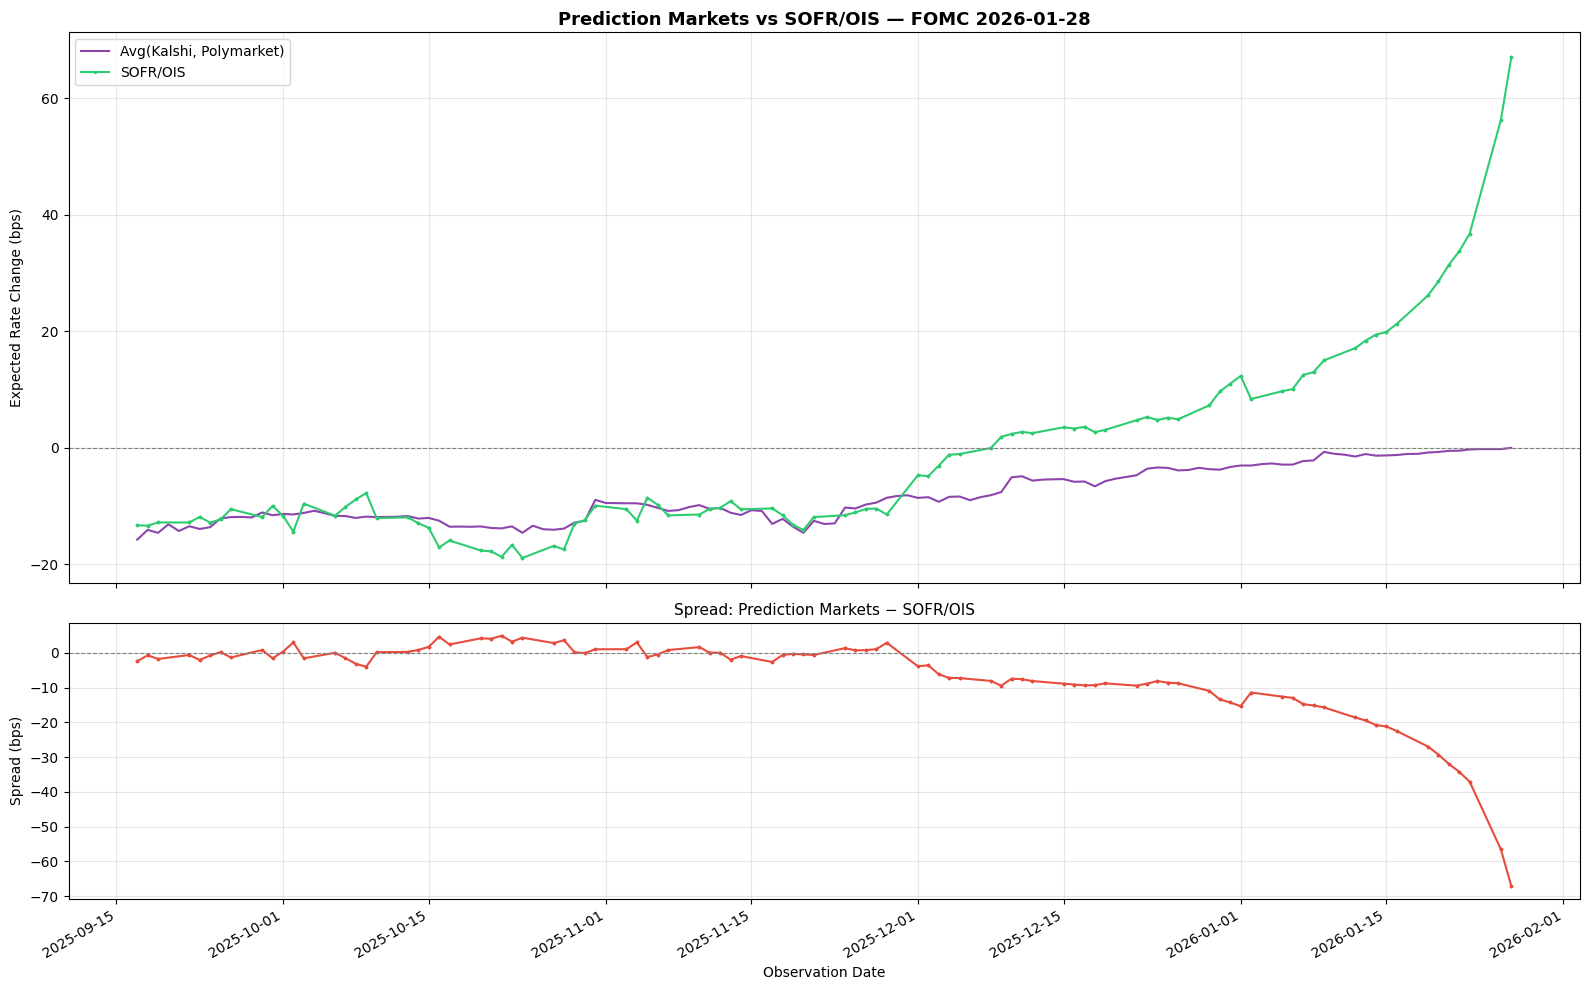

Spread stats (where both available):
  Mean:   -6.92 bps
  Std:    12.10 bps
  Min:    -67.06 bps
  Max:    4.89 bps
  N obs:  285


In [4]:
meeting = "2026-01-28"
mdf = df[df["decision_date"] == meeting].sort_values("observed_day_pst").copy()

mdf["predmkt_avg_bps"] = mdf[["kalshi_expected_bps", "poly_expected_bps"]].mean(axis=1)
mdf["spread_bps"] = mdf["predmkt_avg_bps"] - mdf["sofr_expected_bps"]

mask = mdf[["predmkt_avg_bps", "sofr_expected_bps"]].notna().all(axis=1)
mdf_clean = mdf[mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(mdf["observed_day_pst"], mdf["predmkt_avg_bps"],
         label="Avg(Kalshi, Polymarket)", color="#8e44ad", linewidth=1.5)
sofr_mask = mdf["sofr_expected_bps"].notna()
ax1.plot(mdf.loc[sofr_mask, "observed_day_pst"], mdf.loc[sofr_mask, "sofr_expected_bps"],
         label="SOFR/OIS", color="#2ecc71", linewidth=1.5, marker=".", markersize=3)
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_ylabel("Expected Rate Change (bps)")
ax1.set_title(f"Prediction Markets vs SOFR/OIS — FOMC {meeting}", fontsize=13, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(mdf_clean["observed_day_pst"], mdf_clean["spread_bps"],
         color="#e74c3c", linewidth=1.5, marker=".", markersize=3)
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Spread (bps)")
ax2.set_xlabel("Observation Date")
ax2.set_title("Spread: Prediction Markets − SOFR/OIS", fontsize=11)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Spread stats (where both available):")
print(f"  Mean:   {mdf_clean['spread_bps'].mean():.2f} bps")
print(f"  Std:    {mdf_clean['spread_bps'].std():.2f} bps")
print(f"  Min:    {mdf_clean['spread_bps'].min():.2f} bps")
print(f"  Max:    {mdf_clean['spread_bps'].max():.2f} bps")
print(f"  N obs:  {len(mdf_clean)}")

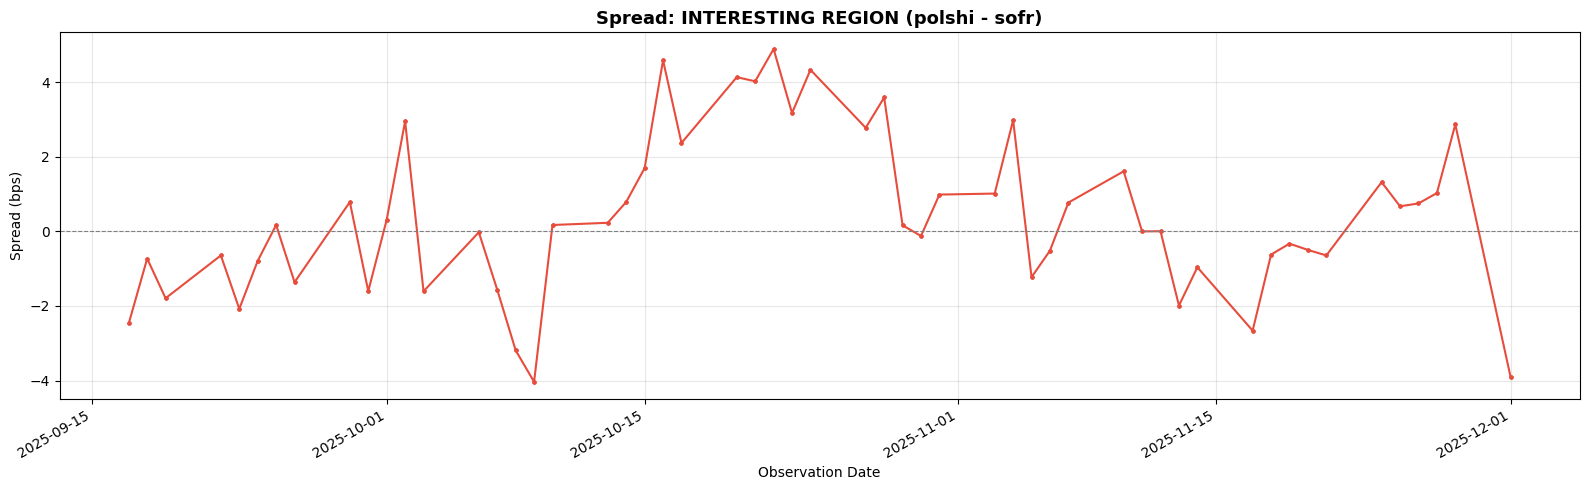

In [12]:
zoom = mdf_clean[
    (mdf_clean["observed_day_pst"] >= pd.Timestamp("2025-09-15")) &
    (mdf_clean["observed_day_pst"] <= pd.Timestamp("2025-12-01"))
]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(zoom["observed_day_pst"], zoom["spread_bps"],
        color="#e74c3c", linewidth=1.5, marker=".", markersize=4)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Spread (bps)")
ax.set_xlabel("Observation Date")
ax.set_title("Spread: INTERESTING REGION (polshi - sofr)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

def ou_analysis(spread: pd.Series, dt: float = 1.0, label: str = ""):
    """
    Full Ornstein-Uhlenbeck analysis à la Avellaneda & Lee.
    
    Estimates parameters via:
      1. AR(1) OLS regression (quick)
      2. Exact MLE (more rigorous)
    Then runs ADF test and computes trading metrics.
    """
    s = spread.dropna().values
    if len(s) < 10:
        return None

    # --- AR(1) OLS: S_{t+1} = a + b * S_t + eps ---
    S_t = s[:-1]
    S_t1 = s[1:]
    n = len(S_t)

    b_ols = (np.sum((S_t - S_t.mean()) * (S_t1 - S_t1.mean())) /
             np.sum((S_t - S_t.mean()) ** 2))
    a_ols = S_t1.mean() - b_ols * S_t.mean()
    residuals = S_t1 - (a_ols + b_ols * S_t)
    sigma_eps = np.std(residuals, ddof=2)

    if b_ols <= 0 or b_ols >= 1:
        kappa_ols = np.nan
        halflife_ols = np.nan
    else:
        kappa_ols = -np.log(b_ols) / dt
        halflife_ols = np.log(2) / kappa_ols

    mu_ols = a_ols / (1 - b_ols) if abs(1 - b_ols) > 1e-12 else np.nan
    sigma_ou_ols = sigma_eps * np.sqrt(2 * kappa_ols / (1 - b_ols**2)) if (
        not np.isnan(kappa_ols) and (1 - b_ols**2) > 0) else np.nan
    sigma_eq_ols = sigma_ou_ols / np.sqrt(2 * kappa_ols) if (
        not np.isnan(kappa_ols) and kappa_ols > 0) else np.nan

    # --- Exact MLE ---
    def neg_log_likelihood(params):
        kappa, mu, sigma = params
        if kappa <= 0 or sigma <= 0:
            return 1e12
        e_kdt = np.exp(-kappa * dt)
        var = (sigma**2 / (2 * kappa)) * (1 - e_kdt**2)
        if var <= 0:
            return 1e12
        predicted = mu + (S_t - mu) * e_kdt
        ll = -0.5 * n * np.log(2 * np.pi * var) - 0.5 * np.sum((S_t1 - predicted)**2) / var
        return -ll

    k0 = kappa_ols if not np.isnan(kappa_ols) else 0.1
    m0 = mu_ols if not np.isnan(mu_ols) else np.mean(s)
    s0 = sigma_ou_ols if not np.isnan(sigma_ou_ols) else np.std(s)

    res = minimize(neg_log_likelihood, [max(k0, 0.01), m0, max(s0, 0.01)],
                   method="Nelder-Mead", options={"maxiter": 10000})
    kappa_mle, mu_mle, sigma_mle = res.x
    halflife_mle = np.log(2) / kappa_mle if kappa_mle > 0 else np.nan
    sigma_eq_mle = sigma_mle / np.sqrt(2 * kappa_mle) if kappa_mle > 0 else np.nan

    # --- ADF test ---
    adf_stat, adf_pvalue, adf_lags, _, adf_crit, _ = adfuller(s, maxlag=int(np.sqrt(len(s))), autolag="AIC")

    # --- s-score (Avellaneda & Lee) ---
    s_score = (s[-1] - mu_mle) / sigma_eq_mle if sigma_eq_mle > 0 else np.nan

    return {
        "label": label,
        "n_obs": len(s),
        "kappa_ols": kappa_ols,
        "mu_ols": mu_ols,
        "sigma_ou_ols": sigma_ou_ols,
        "sigma_eq_ols": sigma_eq_ols,
        "halflife_ols": halflife_ols,
        "kappa_mle": kappa_mle,
        "mu_mle": mu_mle,
        "sigma_mle": sigma_mle,
        "sigma_eq_mle": sigma_eq_mle,
        "halflife_mle": halflife_mle,
        "adf_stat": adf_stat,
        "adf_pvalue": adf_pvalue,
        "adf_1pct": adf_crit["1%"],
        "adf_5pct": adf_crit["5%"],
        "adf_10pct": adf_crit["10%"],
        "s_score": s_score,
        "b_ols": b_ols,
    }


def print_ou_results(r):
    if r is None:
        print("  Insufficient data.\n")
        return
    print(f"  === {r['label']} ({r['n_obs']} obs) ===\n")

    print(f"  AR(1) / OLS Estimates:")
    print(f"    b (AR coeff):        {r['b_ols']:.4f}  (need 0 < b < 1)")
    print(f"    κ (reversion speed): {r['kappa_ols']:.4f}")
    print(f"    μ (long-run mean):   {r['mu_ols']:.2f} bps")
    print(f"    σ_OU:                {r['sigma_ou_ols']:.2f}")
    print(f"    σ_eq (equil. stdev): {r['sigma_eq_ols']:.2f} bps")
    print(f"    Half-life:           {r['halflife_ols']:.1f} days\n")

    print(f"  MLE Estimates:")
    print(f"    κ (reversion speed): {r['kappa_mle']:.4f}")
    print(f"    μ (long-run mean):   {r['mu_mle']:.2f} bps")
    print(f"    σ_OU:                {r['sigma_mle']:.2f}")
    print(f"    σ_eq (equil. stdev): {r['sigma_eq_mle']:.2f} bps")
    print(f"    Half-life:           {r['halflife_mle']:.1f} days\n")

    print(f"  ADF Test:")
    print(f"    Statistic: {r['adf_stat']:.3f}")
    print(f"    p-value:   {r['adf_pvalue']:.4f}")
    print(f"    Critical:  1%={r['adf_1pct']:.3f}  5%={r['adf_5pct']:.3f}  10%={r['adf_10pct']:.3f}")
    reject = "YES ✓" if r['adf_pvalue'] < 0.05 else "NO ✗"
    print(f"    Reject unit root at 5%? {reject}\n")

    print(f"  Current s-score: {r['s_score']:.2f}")
    if abs(r['s_score']) > 1.25:
        direction = "SELL spread" if r['s_score'] > 0 else "BUY spread"
        print(f"    → Signal: {direction} (|s| > 1.25)\n")
    else:
        print(f"    → No signal (|s| < 1.25)\n")

    print(f"  Trading Quality Assessment:")
    hl = r['halflife_mle']
    if 1 <= hl <= 30:
        print(f"    Half-life {hl:.1f}d: GOOD (1-30 day sweet spot)")
    elif hl < 1:
        print(f"    Half-life {hl:.1f}d: TOO FAST (might be noise)")
    else:
        print(f"    Half-life {hl:.1f}d: SLOW (hard to trade profitably)")

    if r['adf_pvalue'] < 0.01:
        print(f"    ADF: STRONG mean reversion evidence")
    elif r['adf_pvalue'] < 0.05:
        print(f"    ADF: Moderate mean reversion evidence")
    elif r['adf_pvalue'] < 0.10:
        print(f"    ADF: Weak evidence (borderline)")
    else:
        print(f"    ADF: NO evidence of mean reversion")
    print()

In [14]:
# --- OU analysis on the INTERESTING REGION only (2025-09-15 to 2025-12-01, FOMC 2026-01-28) ---

r_interesting = ou_analysis(zoom.set_index("observed_day_pst")["spread_bps"],
                            dt=1.0, label="PredMkt − SOFR: Interesting Region (Sep-Dec 2025, FOMC 2026-01-28)")
print_ou_results(r_interesting)

  === PredMkt − SOFR: Interesting Region (Sep-Dec 2025, FOMC 2026-01-28) (162 obs) ===

  AR(1) / OLS Estimates:
    b (AR coeff):        0.8603  (need 0 < b < 1)
    κ (reversion speed): 0.1505
    μ (long-run mean):   0.33 bps
    σ_OU:                1.20
    σ_eq (equil. stdev): 2.19 bps
    Half-life:           4.6 days

  MLE Estimates:
    κ (reversion speed): 0.1505
    μ (long-run mean):   0.33 bps
    σ_OU:                1.19
    σ_eq (equil. stdev): 2.17 bps
    Half-life:           4.6 days

  ADF Test:
    Statistic: -2.296
    p-value:   0.1731
    Critical:  1%=-3.472  5%=-2.880  10%=-2.577
    Reject unit root at 5%? NO ✗

  Current s-score: -1.95
    → Signal: BUY spread (|s| > 1.25)

  Trading Quality Assessment:
    Half-life 4.6d: GOOD (1-30 day sweet spot)
    ADF: NO evidence of mean reversion



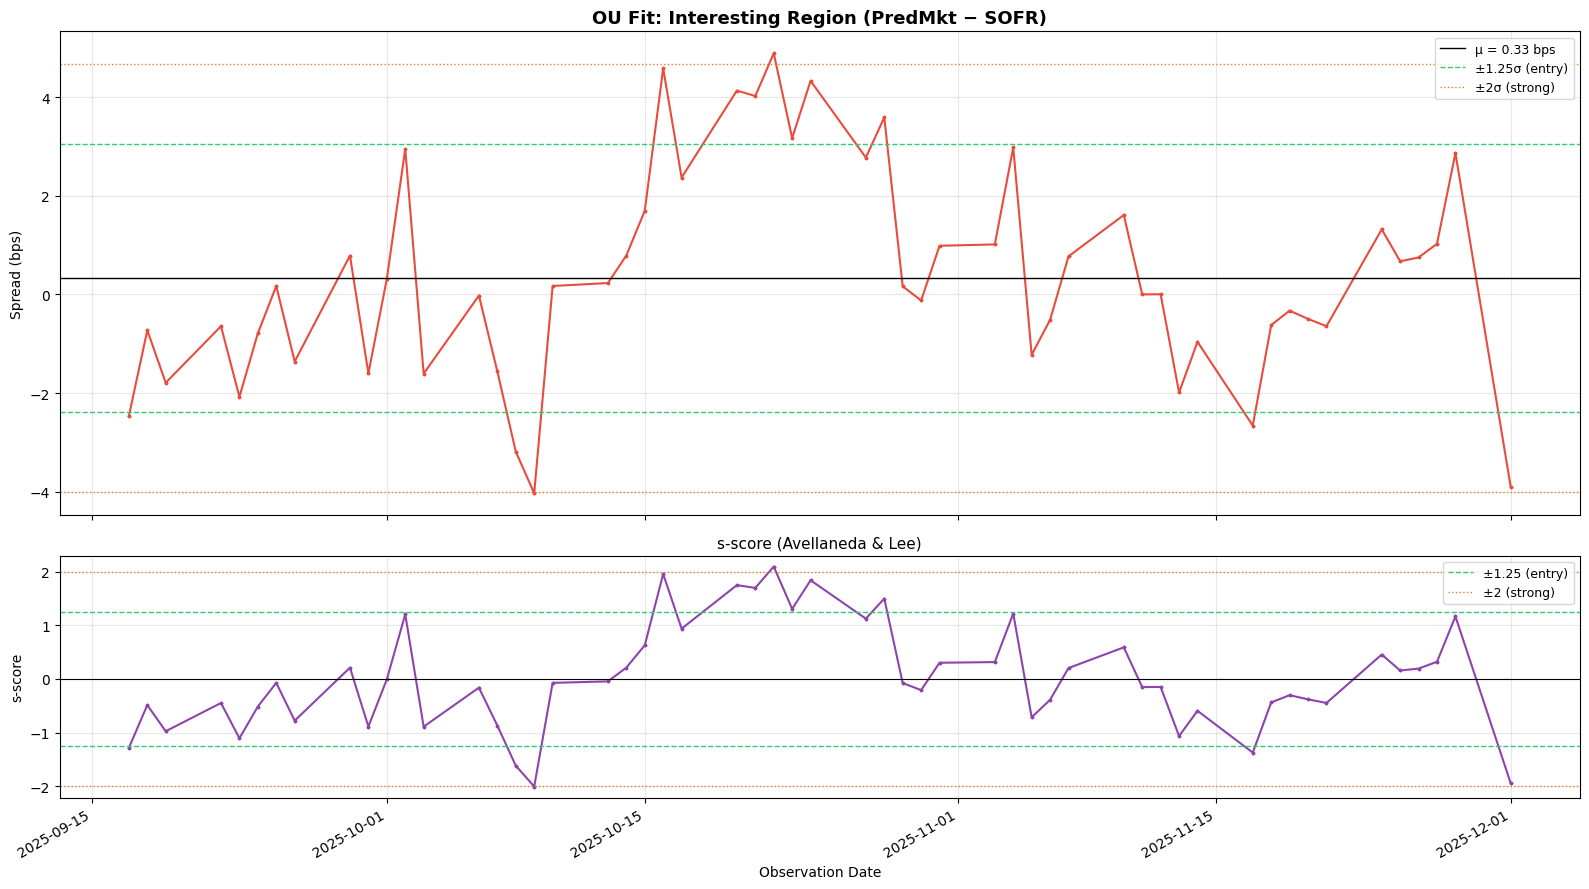

In [16]:
# --- Visualize the OU fit on the interesting region ---

if r_interesting is not None:
    sp = zoom.set_index("observed_day_pst")["spread_bps"].dropna()
    mu = r_interesting["mu_mle"]
    sigma_eq = r_interesting["sigma_eq_mle"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

    ax1.plot(sp.index, sp.values, color="#e74c3c", linewidth=1.5, marker=".", markersize=3)
    ax1.axhline(mu, color="black", linestyle="-", linewidth=1, label=f"μ = {mu:.2f} bps")
    ax1.axhline(mu + 1.25 * sigma_eq, color="#2ecc71", linestyle="--", linewidth=1, label=f"±1.25σ (entry)")
    ax1.axhline(mu - 1.25 * sigma_eq, color="#2ecc71", linestyle="--", linewidth=1)
    ax1.axhline(mu + 2 * sigma_eq, color="#e67e22", linestyle=":", linewidth=1, label=f"±2σ (strong)")
    ax1.axhline(mu - 2 * sigma_eq, color="#e67e22", linestyle=":", linewidth=1)
    ax1.set_ylabel("Spread (bps)")
    ax1.set_title("OU Fit: Interesting Region (PredMkt − SOFR)", fontsize=13, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    s_scores = (sp.values - mu) / sigma_eq
    ax2.plot(sp.index, s_scores, color="#8e44ad", linewidth=1.5, marker=".", markersize=3)
    ax2.axhline(0, color="black", linestyle="-", linewidth=0.8)
    ax2.axhline(1.25, color="#2ecc71", linestyle="--", linewidth=1, label="±1.25 (entry)")
    ax2.axhline(-1.25, color="#2ecc71", linestyle="--", linewidth=1)
    ax2.axhline(2, color="#e67e22", linestyle=":", linewidth=1, label="±2 (strong)")
    ax2.axhline(-2, color="#e67e22", linestyle=":", linewidth=1)
    ax2.set_ylabel("s-score")
    ax2.set_xlabel("Observation Date")
    ax2.set_title("s-score (Avellaneda & Lee)", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()